# 03 — Factor Correlation Analysis

**Purpose**: Visualise Spearman rank correlations between selected features to understand redundancy,
confirm that deduplication worked correctly, and check orthogonality between the five factor groups.

In [1]:
import json, sys, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

df_full = pd.read_parquet(ROOT / 'data' / 'historical_dataset_clean.parquet')
annual = df_full[df_full['period_type'] == 'annual'].copy()
print(f'Annual rows: {len(annual):,}')

Annual rows: 58,307


## 1 — Load selected feature sets

In [2]:
feat_sets = {}
for h in ['1y', '3y', '5y']:
    p = ROOT / 'models' / f'feature_sets_{h}.json'
    if p.exists():
        with open(p) as f:
            feat_sets[h] = json.load(f)['features']
        print(f'{h}: {len(feat_sets[h])} features')
    else:
        print(f'MISSING: {p} — run scripts/run_feature_selection.py')

1y: 46 features
3y: 47 features
5y: 46 features


## 2 — Spearman correlation heatmap (1y selected features)

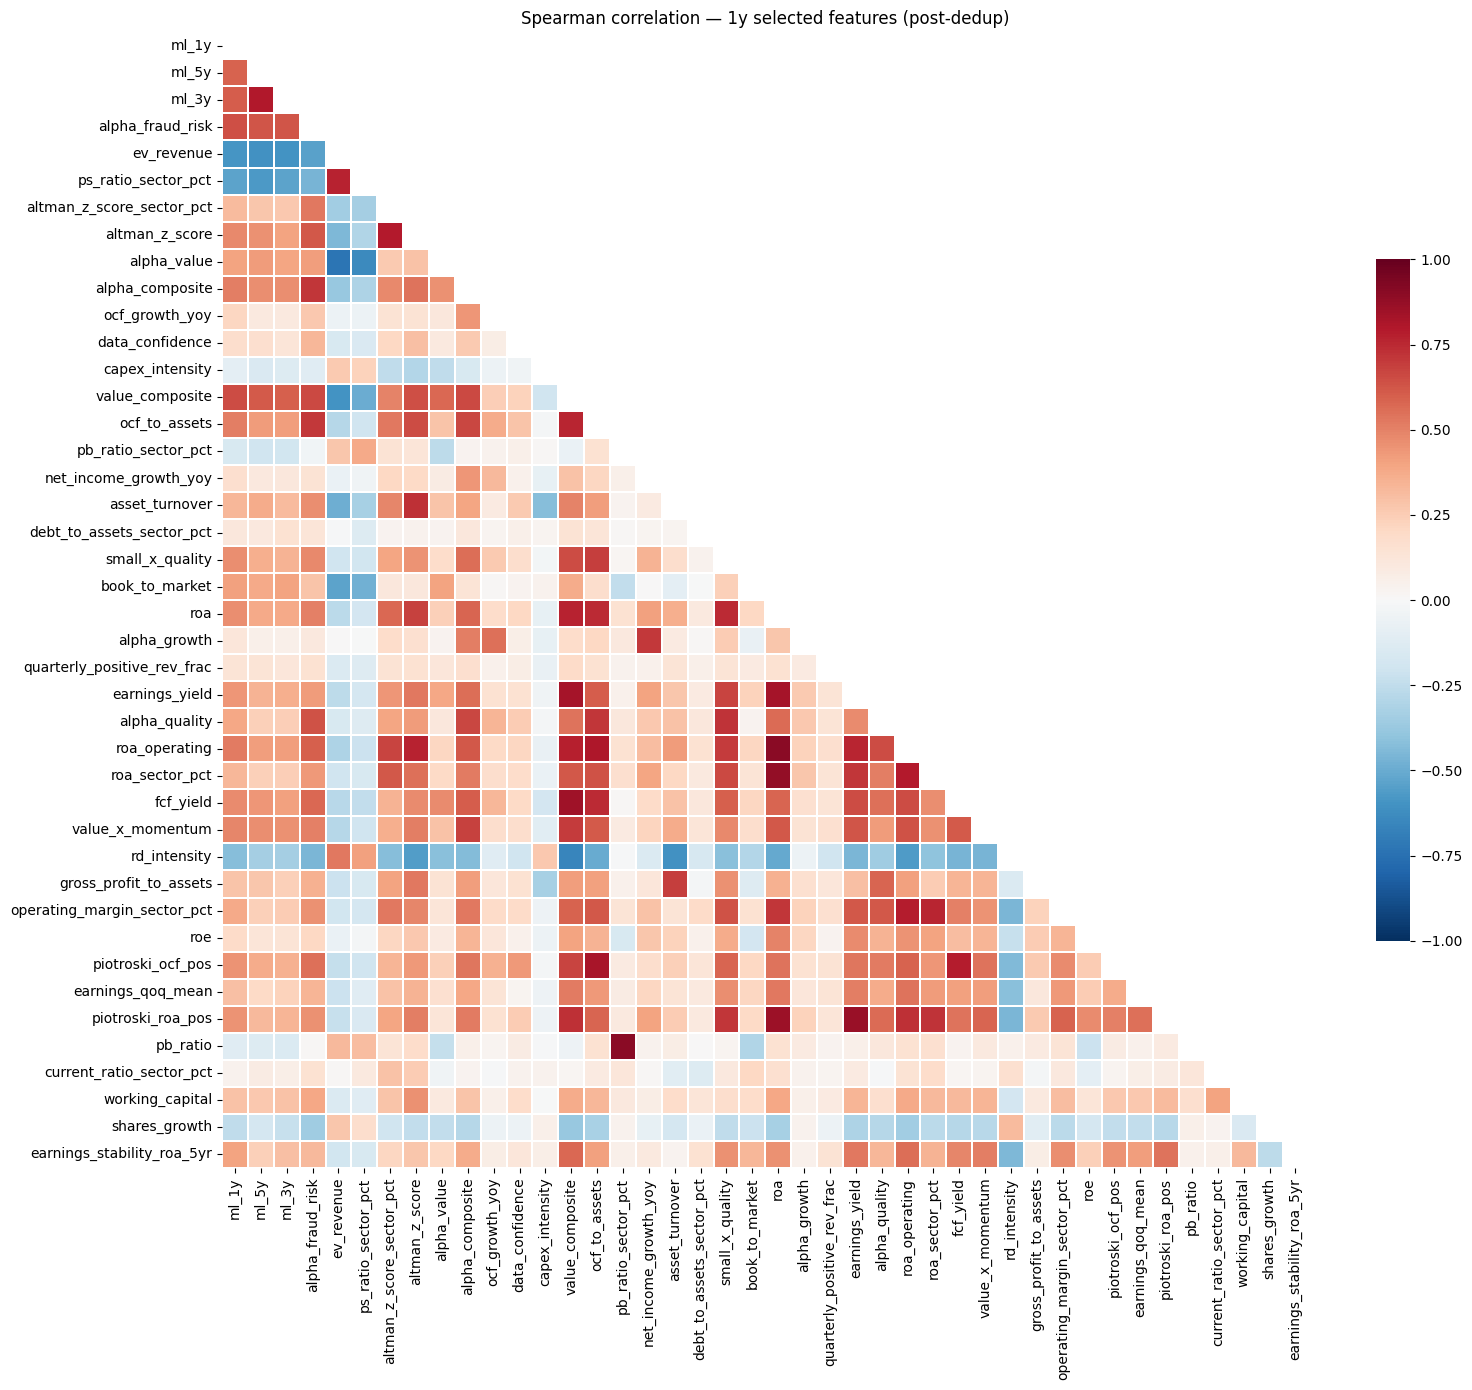

Max |r| off-diagonal (1y): 0.9053  (should be <= 0.90 after dedup)


In [3]:
def spearman_corr_matrix(df, features):
    valid = [f for f in features if f in df.columns]
    sub = df[valid].dropna(how='all')
    n = len(valid)
    corr = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            mask = sub[valid[i]].notna() & sub[valid[j]].notna()
            if mask.sum() < 30:
                corr[i, j] = np.nan
            else:
                corr[i, j], _ = stats.spearmanr(sub.loc[mask, valid[i]], sub.loc[mask, valid[j]])
    return pd.DataFrame(corr, index=valid, columns=valid)

if '1y' in feat_sets:
    corr_1y = spearman_corr_matrix(annual, feat_sets['1y'])
    fig, ax = plt.subplots(figsize=(16, 14))
    mask = np.zeros_like(corr_1y, dtype=bool)
    mask[np.triu_indices_from(mask)] = True
    sns.heatmap(corr_1y, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                ax=ax, xticklabels=True, yticklabels=True, linewidths=0.3,
                cbar_kws={'shrink': 0.6})
    ax.set_title('Spearman correlation — 1y selected features (post-dedup)')
    plt.tight_layout()
    plt.show()
    
    # Confirm max off-diagonal |r| <= 0.90
    off_diag = corr_1y.values.copy()
    np.fill_diagonal(off_diag, 0)
    max_r = np.nanmax(np.abs(off_diag))
    print(f'Max |r| off-diagonal (1y): {max_r:.4f}  (should be <= 0.90 after dedup)')

## 3 — Alpha factor cross-correlation

Alpha columns: ['alpha_value', 'alpha_quality', 'alpha_momentum', 'alpha_growth', 'alpha_fraud_risk', 'alpha_composite']


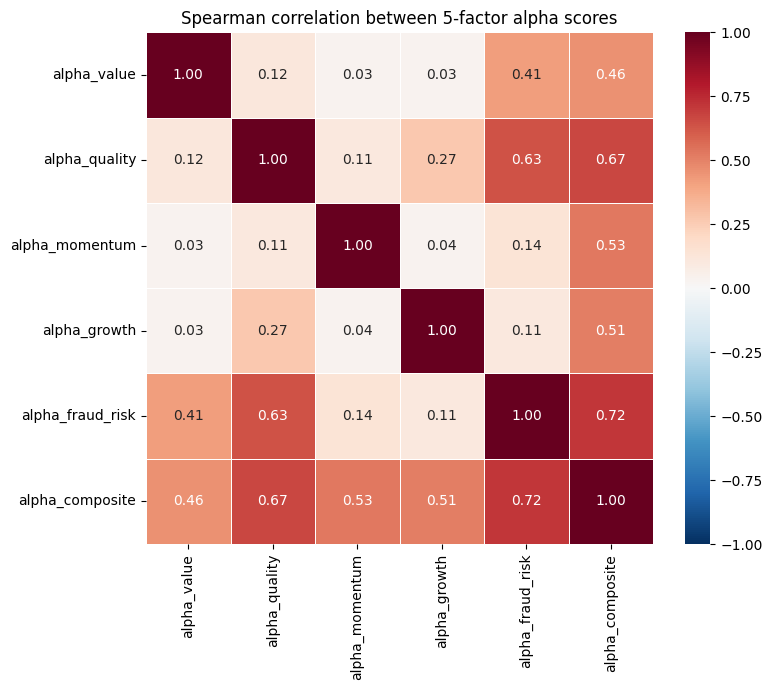

In [4]:
alpha_cols = [c for c in annual.columns if c.startswith('alpha_')]
print('Alpha columns:', alpha_cols)

if len(alpha_cols) >= 2:
    corr_alpha = spearman_corr_matrix(annual, alpha_cols)
    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(corr_alpha, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, ax=ax, linewidths=0.5)
    ax.set_title('Spearman correlation between 5-factor alpha scores')
    plt.tight_layout()
    plt.show()

## 4 — High-correlation pairs (all candidates, not just selected)

In [5]:
summary_path = ROOT / 'reports' / 'feature_selection_summary.csv'
if summary_path.exists():
    sel_df = pd.read_csv(summary_path)
    h1y = sel_df[(sel_df['horizon'] == '1y') & sel_df['selected'].fillna(False)]
    feats = [f for f in h1y['feature'].tolist() if f in annual.columns]
    
    if feats:
        corr_m = spearman_corr_matrix(annual, feats)
        # Find pairs above 0.70
        pairs = []
        cols = corr_m.columns.tolist()
        for i in range(len(cols)):
            for j in range(i+1, len(cols)):
                r = corr_m.iloc[i, j]
                if not np.isnan(r) and abs(r) > 0.70:
                    pairs.append({'feature_a': cols[i], 'feature_b': cols[j], 'r': round(r, 4)})
        pairs_df = pd.DataFrame(pairs).sort_values('r', key=abs, ascending=False)
        print(f'High-correlation pairs (|r|>0.70) among 1y selected features: {len(pairs_df)}')
        if len(pairs_df):
            print(pairs_df.to_string(index=False))

High-correlation pairs (|r|>0.70) among 1y selected features: 38
                feature_a                   feature_b       r
      pb_ratio_sector_pct                    pb_ratio  0.9053
                      roa               roa_operating  0.9026
                      roa              roa_sector_pct  0.8801
           earnings_yield           piotroski_roa_pos  0.8641
                      roa           piotroski_roa_pos  0.8574
          value_composite                   fcf_yield  0.8490
          value_composite              earnings_yield  0.8336
                      roa              earnings_yield  0.8311
            ocf_to_assets           piotroski_ocf_pos  0.8231
            ocf_to_assets               roa_operating  0.8123
                    ml_5y                       ml_3y  0.8031
altman_z_score_sector_pct              altman_z_score  0.7911
            roa_operating              roa_sector_pct  0.7895
            roa_operating operating_margin_sector_pct  0.7833
     